# **External validation on LGMR product**

In [144]:
from geostat_isoscapes_tools import utils,plot_utils
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from scipy import odr
def linear_model(B, x):
    return B[0]*x+B[1]

**First, let us load the dataset (adapt the code to the local path to this dataset)**

In [145]:
lgmr_data= utils.load_xarray_datarray('/media/luluxette/T7_Shield/pdm/LGMR_d18Op_climo.nc')
# keep only the ages between 11 and 20 ka BP form this xarray
lgmr_data = lgmr_data.sel(age=slice(11000, 20000))
# round lats at the 4th decimal
lgmr_data = lgmr_data.astype('float64').assign_coords(lat=lgmr_data.lat.astype('float64').round(3))
# convert to df
lgmr_data_df = lgmr_data.to_dataframe().reset_index()
# convert to pos-neg longitudes
lgmr_data_df['lon']=utils.convert_lon_0_360_to_neg180_180(np.asarray(lgmr_data_df.lon))

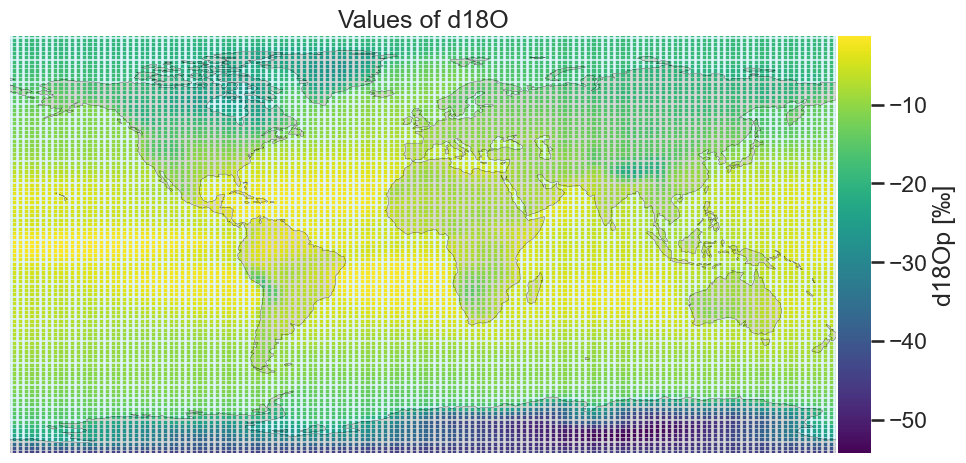

In [26]:
fig,ax = plot_utils.plot_latlon_platecarree_df(lgmr_data_df[lgmr_data_df.age==11100.0],s=5)

In [27]:
print(lgmr_data_df.age.unique())

[11100. 11300. 11500. 11700. 11900. 12100. 12300. 12500. 12700. 12900.
 13100. 13300. 13500. 13700. 13900. 14100. 14300. 14500. 14700. 14900.
 15100. 15300. 15500. 15700. 15900. 16100. 16300. 16500. 16700. 16900.
 17100. 17300. 17500. 17700. 17900. 18100. 18300. 18500. 18700. 18900.
 19100. 19300. 19500. 19700. 19900.]


Compute the error metrics (MAE, RMSE, R2) between the LGMR data and the kriged predictions at these points



In [146]:
# 1. load the kriged product
kriged_ds = utils.load_xarray_datarray(fn='../output/kriging/runs_wip/2026-06-15-PHIS/vario_n10/res200/speleothems_isoscapes_11_to_20kaBP.nc')
kriged_df = kriged_ds.to_dataframe().reset_index()
# kriged_df = kriged_df[kriged_df.confidence_flag<3]

In [147]:
kriged_df[kriged_df.time==kriged_df.time.values[0]]

,time,lat,lon,d18Op,ss_pred,confidence_flag
0,11200.0,-90.000,-180.0,-57.673864,49.582344,3.0
1,11200.0,-90.000,-177.5,-57.673697,49.582078,3.0
2,11200.0,-90.000,-175.0,-57.674144,49.582793,3.0
3,11200.0,-90.000,-172.5,-57.671413,49.578424,3.0
4,11200.0,-90.000,-170.0,-57.673053,49.581048,3.0
...,...,...,...,...,...,...
13099,11200.0,84.316,167.5,NaN,NaN,NaN
13100,11200.0,84.316,170.0,NaN,NaN,NaN
13101,11200.0,84.316,172.5,NaN,NaN,NaN
13102,11200.0,84.316,175.0,NaN,NaN,NaN


In [148]:
kriged_df.lat.min()

-90.0

In [149]:
# 2. Construct a dataframe with the kriged values and the corresponding LGMR values at the same location and time 

# Each bin [t, t+200] of the kriged_df overlaps 50% with the bin [t-100, t+100] and 50% with the bin [t+100, t+300] of the LGMR dataframe.
df_A = kriged_df.rename(columns={"time": "time_A", "d18Op": "d18Op_A"})
df_B = lgmr_data_df.rename(columns={"age": "time_B", "d18Op": "d18Op_B"})

df_B["time_A_lo"] = df_B["time_B"] - 100
df_B["time_A_hi"] = df_B["time_B"] + 100 
df_merged = (df_B.merge(df_A.rename(columns={"time_A": "time_A_lo", "d18Op_A": "d18Op_A_lo"}), on=["lat", "lon", "time_A_lo"], how="inner").merge(df_A.rename(columns={"time_A": "time_A_hi", "d18Op_A": "d18Op_A_hi"}),on=["lat", "lon", "time_A_hi"], how="inner"))
# Overlap-weighted mean:
df_merged["d18Op_A_aligned"] = 0.5 * df_merged["d18Op_A_lo"] + 0.5 * df_merged["d18Op_A_hi"]

df_comparison = df_merged[["lat", "lon", "time_B", "d18Op_A_aligned", "d18Op_B"]].copy()
df_comparison.rename(columns={"time_B": "time", "d18Op_B": "d18Op_LGMR", "d18Op_A_aligned": "d18Op_kriged"},inplace=True)

In [150]:
df_comparison['bias']=df_comparison['d18Op_kriged']-df_comparison['d18Op_LGMR']
df_comparison['diff_norm']=df_comparison['bias']/np.abs(df_comparison['d18Op_LGMR'])
df_comparison['rmsd']=np.sqrt((df_comparison['bias'])**2)

In [151]:
df_comparison.dropna(subset=['d18Op_kriged', 'd18Op_LGMR'], inplace=True)

In [152]:
df_comparison.lat.describe()

count    275480.000000
mean          4.520416
std          58.370520
min         -90.000000
25%         -67.263000
50%          21.789000
75%          55.895000
max          84.316000
Name: lat, dtype: float64

0.978380276751702 0.0


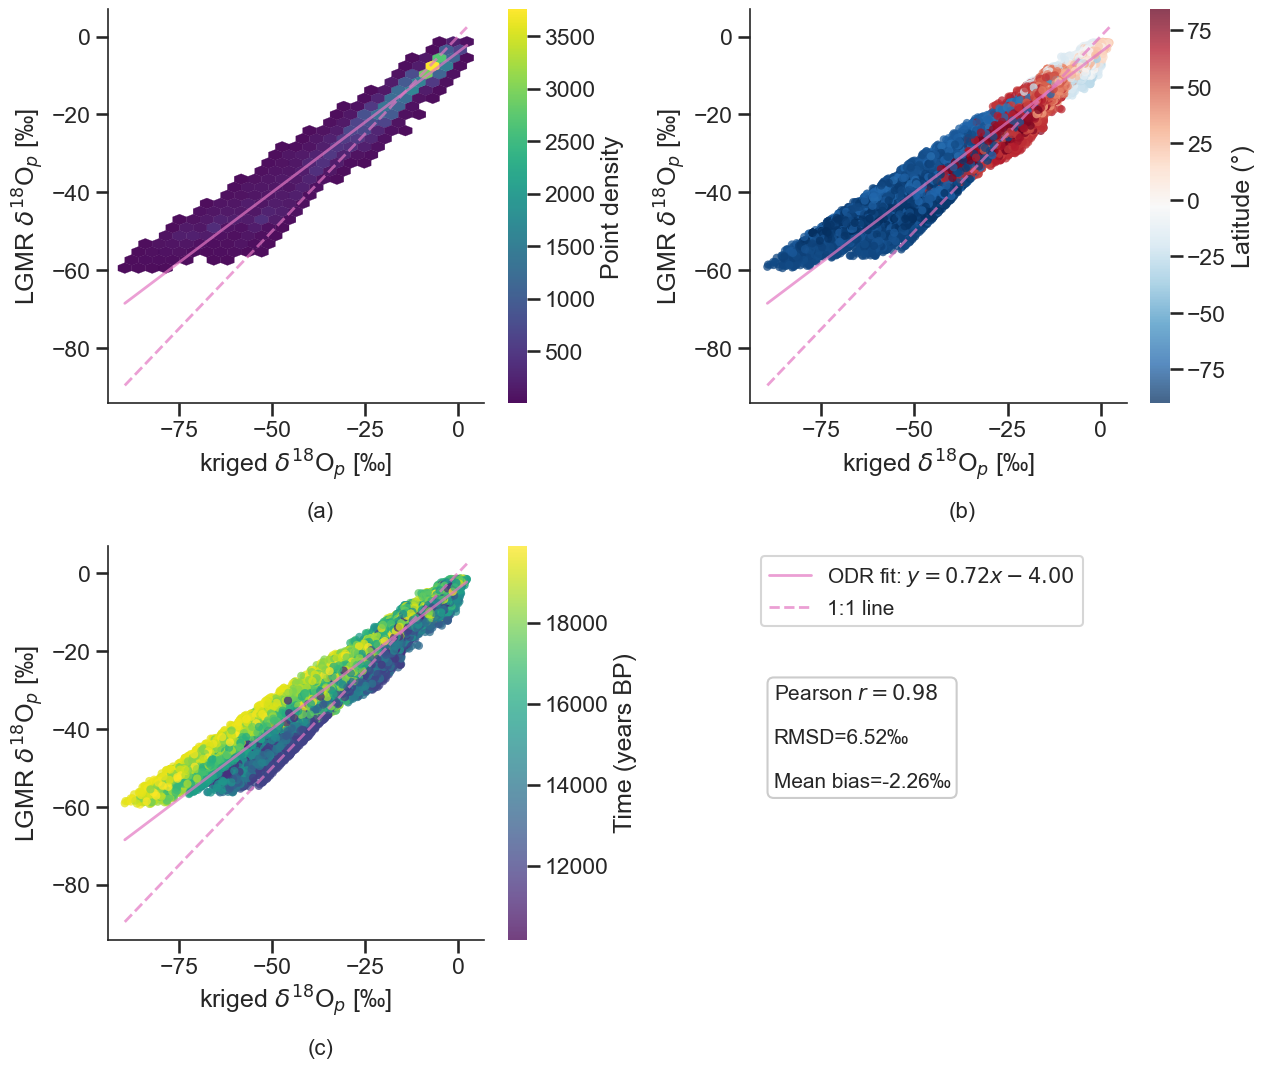

In [153]:
# df = df_comparison[df_comparison.time.between(11000, 12000)]
# define df as a random sample of 5000 points from df comparison 
df = df_comparison.sample(n=50000, random_state=42)
x = 'd18Op_kriged'
y = 'd18Op_LGMR'

# metrics
r, p_value = pearsonr(df[x], df[y])
print(r,p_value)
rmse = utils.RMSE(df[x], df[y])
bias = np.mean(df[x]-df[y])

# plot
fig = plt.figure(figsize=(13, 11))
ax_density = fig.add_subplot(2, 2, 1)
ax_scatter = fig.add_subplot(2, 2, 2)
ax_time = fig.add_subplot(2, 2, 3)
ax_info = fig.add_subplot(2, 2, 4)
axes = [ax_density, ax_scatter, ax_time]

# Top-left: density plot
hb = ax_density.hexbin(
    df[x],
    df[y],
    gridsize=25,
    cmap='viridis',
    mincnt=1,
    linewidths=0.2,
    alpha=0.95,
)
cbar = fig.colorbar(hb, ax=ax_density, label='Point density')
cbar.outline.set_visible(False)
ax_density.set_xlabel(r'kriged $\delta^{18}$O$_p$ [‰]')
ax_density.set_ylabel(r'LGMR $\delta^{18}$O$_p$ [‰]')

# Top-right: legend + metrics box
ax_info.axis('off')
ax_info.text(
    0.05, 0.65,
    fr'Pearson $r={r:.2f}$' '\n\n'
    fr'RMSD={rmse:.2f}‰' '\n\n'
    r'Mean bias=' f'{bias:.2f}‰',
    fontsize=15,
    va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='none', edgecolor='0.8'),
)

# Bottom row: scatter plots colored by latitude and time
sc = ax_scatter.scatter(
    df[x],
    df[y],
    c=df['lat'],
    cmap='RdBu_r',
    s=35,
    alpha=0.75,
    edgecolors='none',
)
cbar = fig.colorbar(sc, ax=ax_scatter, label='Latitude (°)')
cbar.outline.set_visible(False)
ax_scatter.set_xlabel(r'kriged $\delta^{18}$O$_p$ [‰]')
ax_scatter.set_ylabel(r'LGMR $\delta^{18}$O$_p$ [‰]')

# Create a reversed normalization so the displayed colorbar is inverted without changing the colors
vmin, vmax = df['time'].min(), df['time'].max()
norm_time = plt.Normalize(vmin=vmax, vmax=vmin)
sc_time = ax_time.scatter(
    df[x],
    df[y],
    c=df['time'],
    cmap='viridis',
    norm=norm_time,
    s=35,
    alpha=0.75,
    edgecolors='none',
)
cbar = fig.colorbar(sc_time, ax=ax_time, label='Time (years BP)')
cbar.outline.set_visible(False)
ax_time.set_xlabel(r'kriged $\delta^{18}$O$_p$ [‰]')
ax_time.set_ylabel(r'LGMR $\delta^{18}$O$_p$ [‰]')

# reference line and common layout
min_val = min(df[x].min(), df[y].min())
max_val = max(df[x].max(), df[y].max())

# Linear fit
model = odr.Model(linear_model)
data = odr.Data(df[x], df[y])
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()
slope, intercept = out.beta
x_vals = np.linspace(min_val, max_val, 200)
y_vals = intercept + slope * x_vals

for ax, label in zip([ax_density, ax_scatter, ax_time], ['(a)', '(b)', '(c)']):
    color= 'tab:pink'
    ax.plot(x_vals, y_vals, linewidth=2, label=fr'ODR fit: $y={slope:.2f}x {intercept:+.2f}$', alpha=0.7, color=color)
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2, label='1:1 line', color=color, alpha=0.7)
    ax.text(0.6, -0.3, label, transform=ax.transAxes, fontsize=16, va='bottom', ha='right')
    sns.despine(ax=ax)

# add legend in the top-right panel
handles, labels = ax_density.get_legend_handles_labels()
ax_info.legend(handles, labels, loc='upper left', fontsize=15, frameon=True)

plt.tight_layout()
plt.savefig('../output/essd_figs/fig_LGMR_all_latitudes.png', dpi=400, bbox_inches='tight')
plt.show()